
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 2
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consignas

En esta tarea semanal retomamos la consigna de la tarea anterior, donde simulamos el bloque de cuantización de un ADC de **B** bits en un rango de $±VF$ Volts. Ahora vamos a completar la simulación del ADC incluyendo la capacidad de muestrear a **fs** Hertz.

Para ello se simulará el comportamiento del dispositivo al digitalizar una **senoidal contaminada con un nivel predeterminado de ruido**. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

- frecuencia $f_{0}$ arbitraria, por ejemplo $f_{0}=f_{S}/N=Δ_{f}$

- **energía normalizada**, es decir energía (o varianza) unitaria

Con respecto a los parámetros de la secuencia de ruido, diremos que:

- será de carácter aditivo, es decir la señal que entra al ADC será $s_{R}=s+n$. Siendo n la secuencia que simula la interferencia, y s la senoidal descrita anteriormente.

- La potencia del ruido será $P_{n}=k_{n}.P_{q}$ W siendo el factor k una escala para la potencia del ruido de cuantización $P_{q}=q^{2}/12$.

-  finalmente, n será **incorrelado** y **Gaussiano**.

El ADC que deseamos simular trabajará a una frecuencia de muestreo $f_{S}=1000 Hz$ y tendrá un rango analógico de $±VF=2$ Volts.

Se pide:

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1
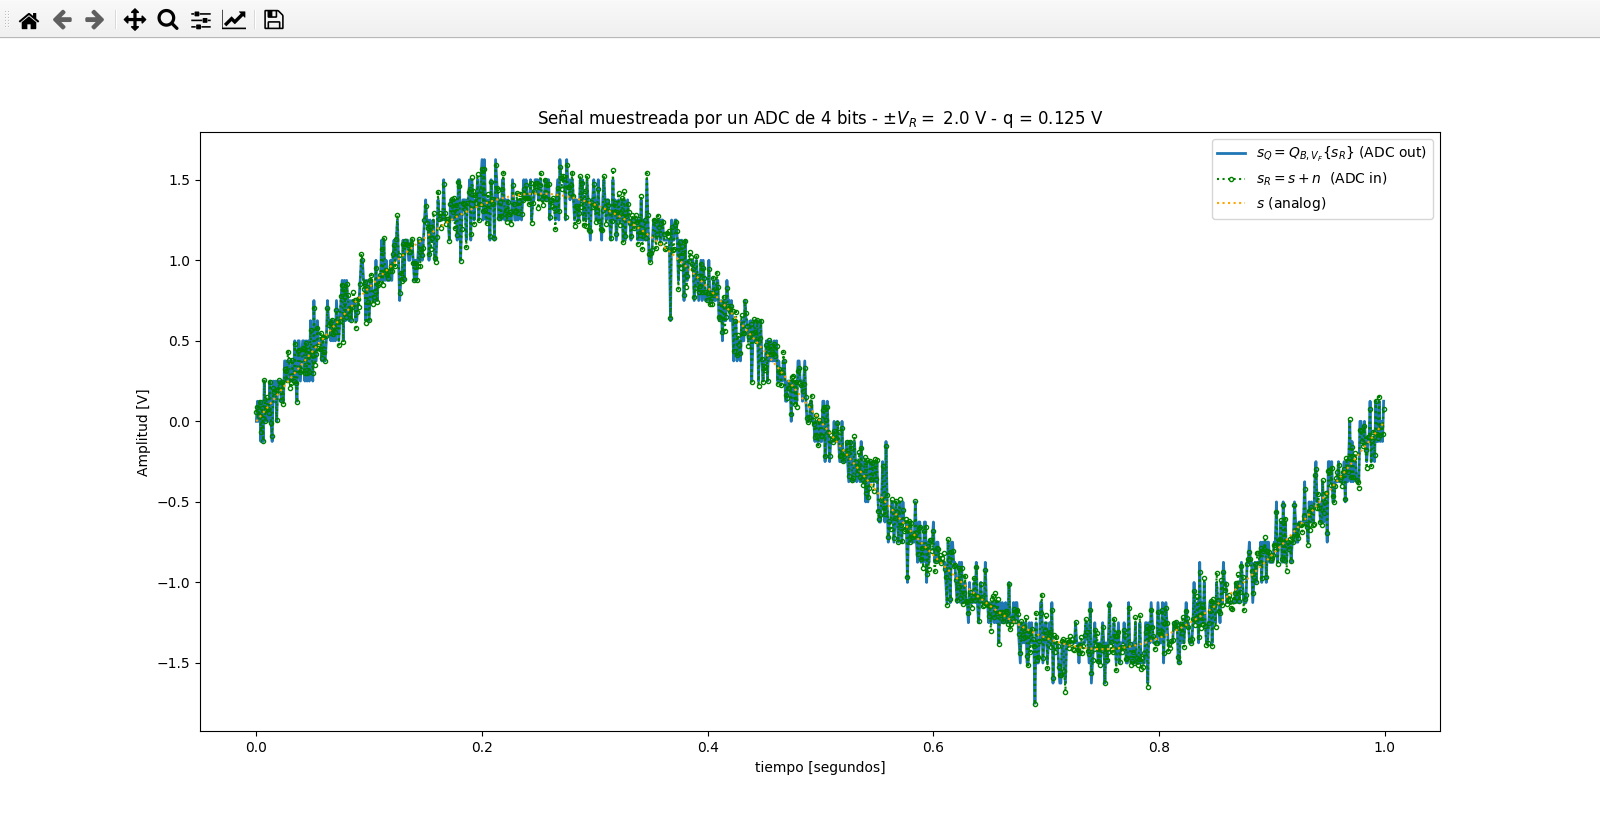
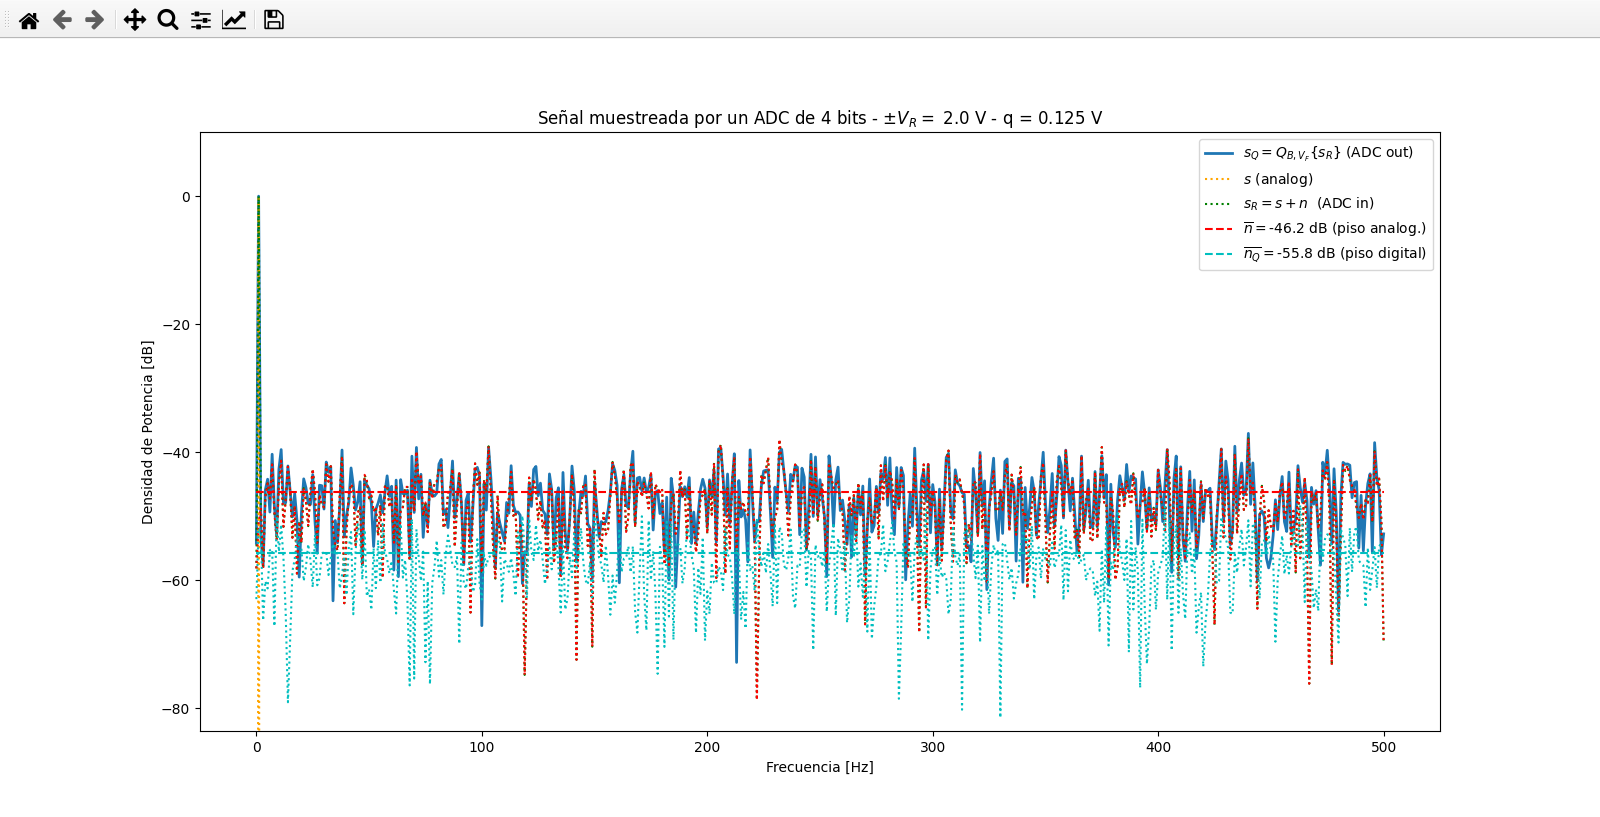
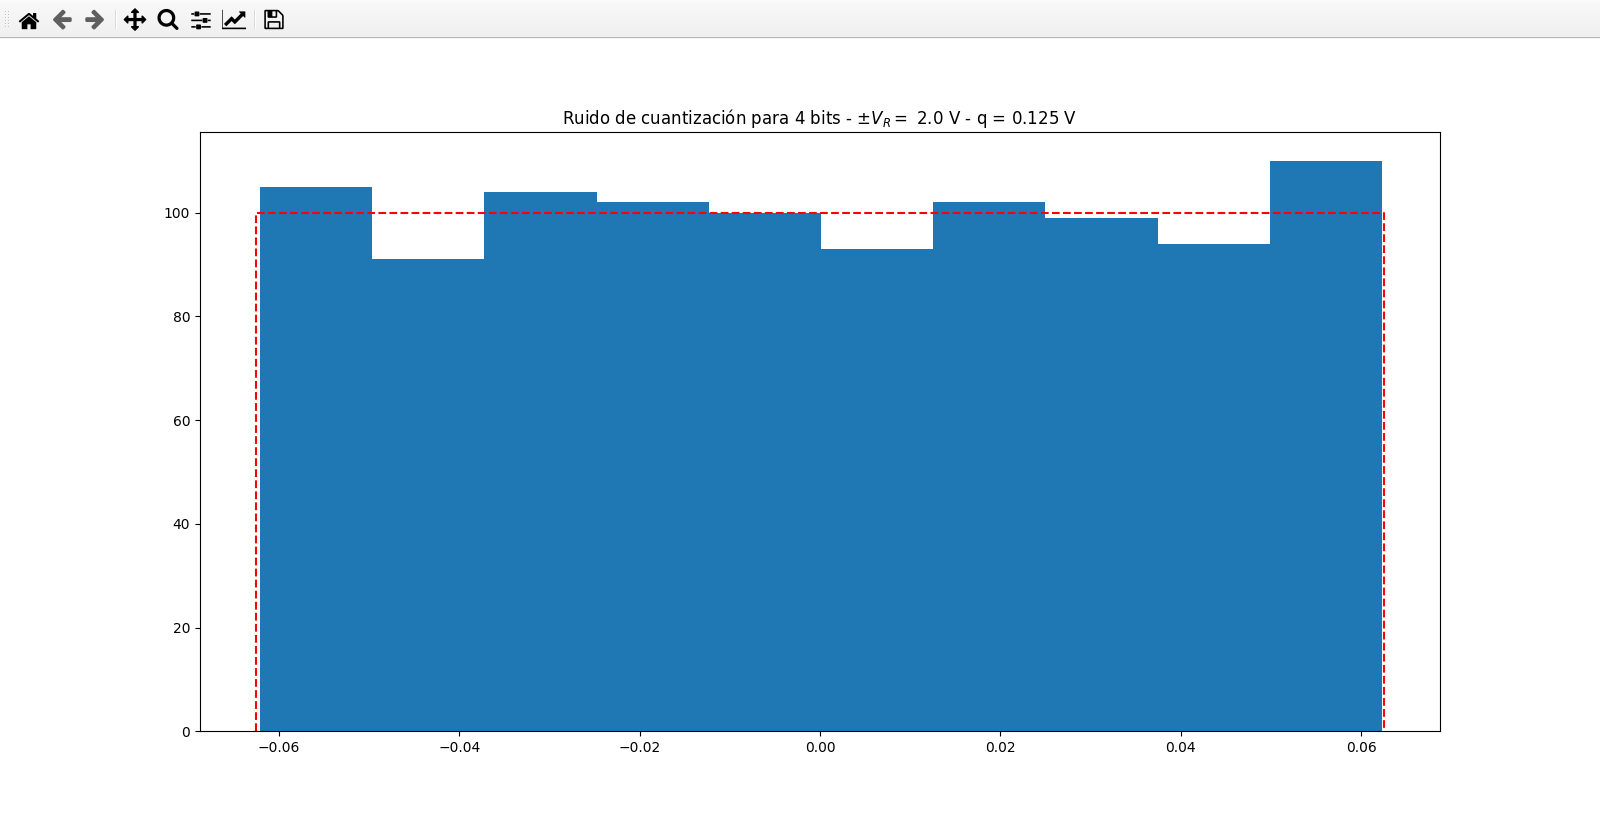

b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}. Discutir los resultados respecto a lo obtenido en a).

Bonus:

- 💎 Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada. (Ver Holton. DSP Principles and App. 6.7 ADC Quantization pag. 387 )
  
- 🤯 Simular el efecto del aliasing junto con el muestreo.

# Resolución del ejercicio 1


En primer lugar, se definen las variables que serán utilizadas a lo largo del trabajo, tales como la frecuencia, el número de muestras y la resolución del ADC (número de bits). Además, se establecen los parámetros de la secuencia de ruido, el cual será de carácter aditivo, incorrelado y Gaussiano. Su potencia estará dada por la ecuación $P_n = k_n \cdot P_q$, donde $k_n$ representa un factor de escala respecto a la potencia del ruido de cuantización, definida matemáticamente como $P_q = \frac{q^2}{12}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Función para sintetizar señales senoidales
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):

    ts = 1/fs

    tt = np.linspace(0, (nn-1)*ts, nn)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    return tt, xx


fs = 1000          # Frecuencia de muestreo (1000 Hz)
N = 1000           
f0 = fs / N        
vmax = np.sqrt(2)  


B = 4              
V_R = 2.0          # Rango analógico +/- 2.0 V
q = (V_R) / (2**B)   # Paso de cuantización
kn = 1            # Factor de escala del ruido de entrada

tt, s = mi_funcion_sen(vmax, 0, f0, 0, N, fs)

Pq = (q**2) / 12   # Potencia del ruido de cuantización teórico
Pn = kn * Pq       # Potencia del ruido analógico

np.random.seed(0)  
n = np.random.normal(0, np.sqrt(Pn), N)

# Señal con ruido
sR = s + n

# Señal cuantizada a la salida del ADC
sQ = np.round(sR / q) * q

### Primer gráfico

A continuación, se presenta el primer gráfico solicitado. En esta figura se pueden comparar visualmente tres curvas superpuestas:
- La señal analógica original pura ($s$).
- La señal de entrada al ADC, que corresponde a la señal original contaminada con ruido gaussiano aditivo ($s_R = s + n$).
- La señal de salida del ADC, resultante del proceso de cuantización con la resolución de 4 bits previamente definida ($s_Q$).

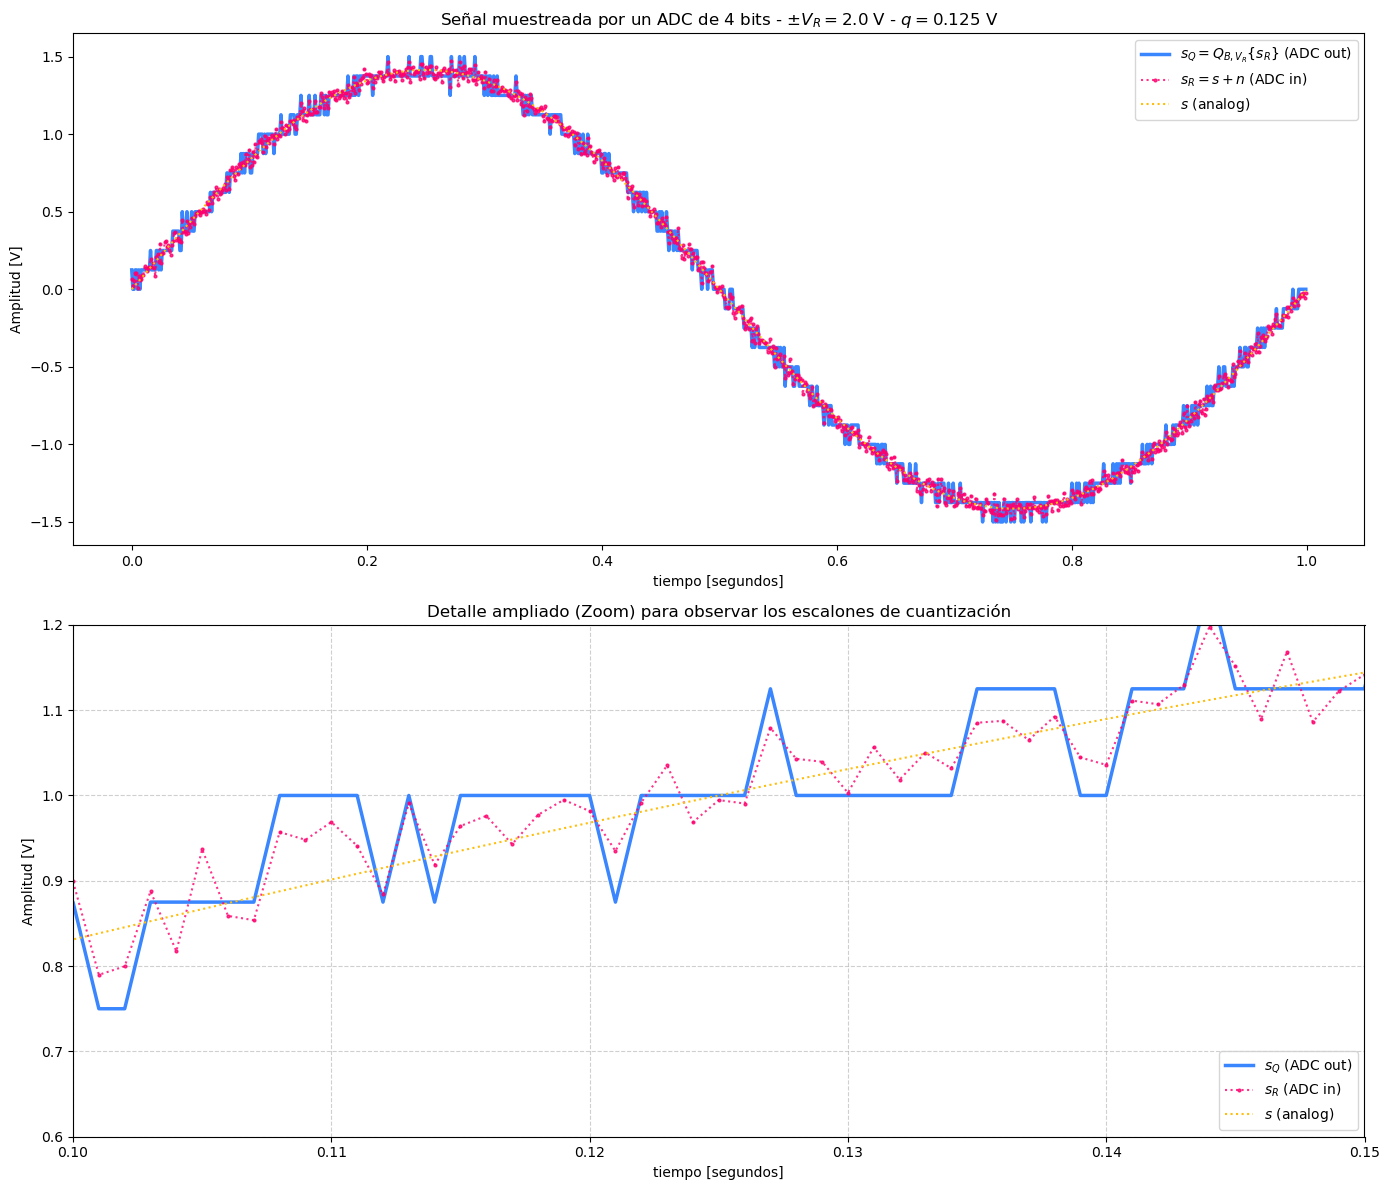

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# --- Gráfico 1: Vista completa original ---
ax1.plot(tt, sQ, label=r'$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)', linewidth=2.5, color='#3A86FF')
ax1.plot(tt, sR, '.:', label=r'$s_R = s + n$ (ADC in)', markersize=4, alpha=0.8, color='#FF006E')
ax1.plot(tt, s, color='#FFBE0B', linestyle=':', label=r'$s$ (analog)')

ax1.set_title(f'Señal muestreada por un ADC de {B} bits - $\pm V_R = {V_R}$ V - $q = {q}$ V')
ax1.set_xlabel('tiempo [segundos]')
ax1.set_ylabel('Amplitud [V]')
ax1.legend(loc='upper right')

# --- Gráfico 2: Vista con zoom ---
ax2.plot(tt, sQ, label=r'$s_Q$ (ADC out)', linewidth=2.5, color='#3A86FF')
ax2.plot(tt, sR, '.:', label=r'$s_R$ (ADC in)', markersize=4, alpha=0.8, color='#FF006E')
ax2.plot(tt, s, color='#FFBE0B', linestyle=':', label=r'$s$ (analog)')


x1, x2 = 0.1, 0.15  
y1, y2 = 0.6, 1.2  
ax2.set_xlim(x1, x2)
ax2.set_ylim(y1, y2)

ax2.set_title('Detalle ampliado (Zoom) para observar los escalones de cuantización')
ax2.set_xlabel('tiempo [segundos]')
ax2.set_ylabel('Amplitud [V]')
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Como se puede apreciar en la gráfica, debido a la baja resolución del ADC ($B = 4$ bits), la señal digitalizada ($s_Q$) presenta una marcada forma escalonada (se aprecia mejor en el gráfico con zoom). Estos saltos discretos en amplitud corresponden exactamente al paso de cuantización establecido de $q = 0.125$ V.

Además,se puede notar que el ruido gaussiano añadido a la señal de entrada ($s_R$) provoca oscilaciones en la salida del ADC. Esto es muy notorio cuando la señal ruidosa fluctúa cerca de un umbral de decisión, haciendo que la señal cuantizada "salte" continuamente entre dos niveles de cuantización adyacentes. 

Podemos decir que el ADC opera de manera lineal en todo el recorrido. Esto se debe a que la amplitud máxima de la senoidal (aproximadamente 1.41 V) no supera el rango dinámico del convertidor analógico-digital ($\pm V_R = 2.0$ V), es decir no se observan recortes en los picos de la señal. 

### Segundo gráfico
A continuación, se procede a generar un segundo gráfico, esta vez en el dominio de la frecuencia. Mediante el uso de la Transformada Rápida de Fourier (FFT), se calcula la Densidad Espectral de Potencia (PSD) en dB para cada una de las señales, lo que nos permite analizar su distribución de energía espectral.

El objetivo principal de esta visualización es observar e interpretar la relación entre los diferentes pisos de ruido presentes en el sistema:
- El piso de ruido analógico ($\bar{n}$), proveniente de la interferencia gaussiana añadida a la señal de entrada.
- El piso de ruido digital o de cuantización ($\bar{n}_Q$), producto de la resolución finita del convertidor (en este caso, de 4 bits).

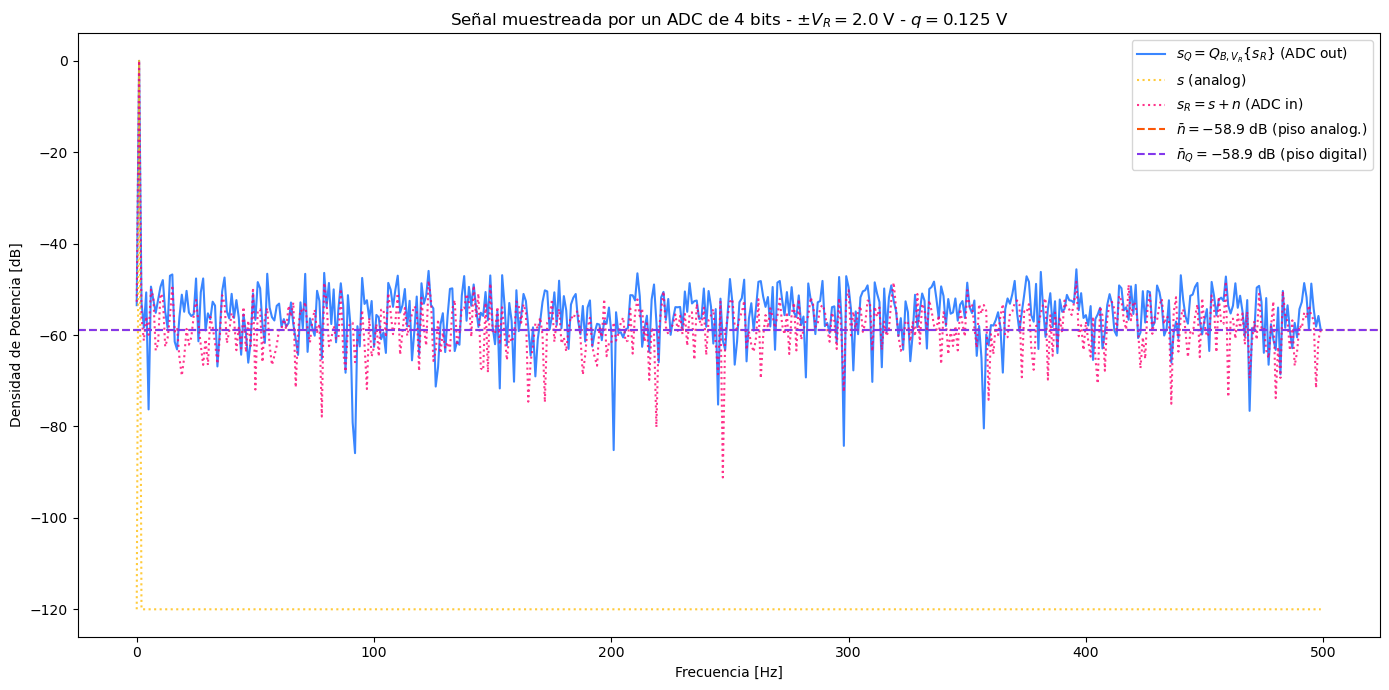

In [3]:
# Transformadas de Fourier normalizadas
S = np.fft.fft(s) / N
SR = np.fft.fft(sR) / N
SQ = np.fft.fft(sQ) / N

# Vector de frecuencias (solo la mitad positiva hasta Nyquist)
freqs = np.fft.fftfreq(N, 1/fs)
pos_freqs = freqs[:N//2]

# Cálculo de Densidad de Potencia en dB
eps = 1e-12 # Pequeña constante para evitar log(0)
psd_s = 10 * np.log10(2 * np.abs(S[:N//2])**2 + eps)
psd_sR = 10 * np.log10(2 * np.abs(SR[:N//2])**2 + eps)
psd_sQ = 10 * np.log10(2 * np.abs(SQ[:N//2])**2 + eps)

# Pisos de ruido teóricos esparcidos en los N/2 bins
floor_digital_dB = 10 * np.log10(Pq / N)
floor_analog_dB = 10 * np.log10(Pn / N)

plt.figure(figsize=(14, 7))

plt.plot(pos_freqs, psd_sQ, label=r'$s_Q = Q_{B,V_R}\{s_R\}$ (ADC out)', color='#3A86FF')
plt.plot(pos_freqs, psd_s, color='#FFBE0B', linestyle=':', label=r'$s$ (analog)', alpha=0.8)
plt.plot(pos_freqs, psd_sR, ':', label=r'$s_R = s + n$ (ADC in)', alpha=0.8, color='#FF006E')

plt.axhline(floor_analog_dB, color='#FB5607', linestyle='--', label=f'$\\bar{{n}} = {floor_analog_dB:.1f}$ dB (piso analog.)')
plt.axhline(floor_digital_dB, color='#8338EC', linestyle='--', label=f'$\\bar{{n}}_Q = {floor_digital_dB:.1f}$ dB (piso digital)')

plt.title(f'Señal muestreada por un ADC de {B} bits - $\pm V_R = {V_R}$ V - $q = {q}$ V')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

Del análisis del espectro de potencias, se pueden extraer varias observaciones importantes. En el extremo izquierdo del gráfico se distingue un claro impulso (similar a una delta de Dirac) que representa la energía concentrada en la frecuencia de la señal senoidal original. Como era de esperarse, este pico espectral dominante se preserva perfectamente tanto en la señal analógica pura como en las versiones con ruido y cuantizadas, destacándose fuertemente por encima del piso de ruido general del sistema.

Además, se observa claramente que el nivel medio del ruido analógico ($\bar{n}$) y el del ruido digital o de cuantización ($\bar{n}_Q$) se encuentran a la misma altura en la gráfica (aproximadamente -58.9 dB). Esto es una consecuencia directa de haber configurado el factor de escala $k_n = 1$ al inicio del experimento, lo que fuerza a que la potencia del ruido gaussiano aditivo sea exactamente igual a la potencia teórica del ruido de cuantización ($P_n = 1 \cdot  P_q$).

### Tercer gráfico

A continuación, se genera un histograma para analizar detalladamente la distribución estadística del error de cuantización ($e_q$). 

Matemáticamente, este error se define como la diferencia instantánea entre la señal a la salida del convertidor y la señal analógica a su entrada ($e_q = s_Q - s_R$). El propósito principal de esta visualización es corroborar si el ruido introducido por el proceso de digitalización se ajusta a la teoría. En un escenario ideal, el error de cuantización se comporta como una variable aleatoria de distribución uniforme, cuyos valores se encuentran estrictamente acotados dentro del intervalo $[-\frac{q}{2}, \frac{q}{2}]$. Para facilitar el análisis visual, el código superpone sobre el histograma empírico la traza teórica correspondiente a esta distribución ideal.

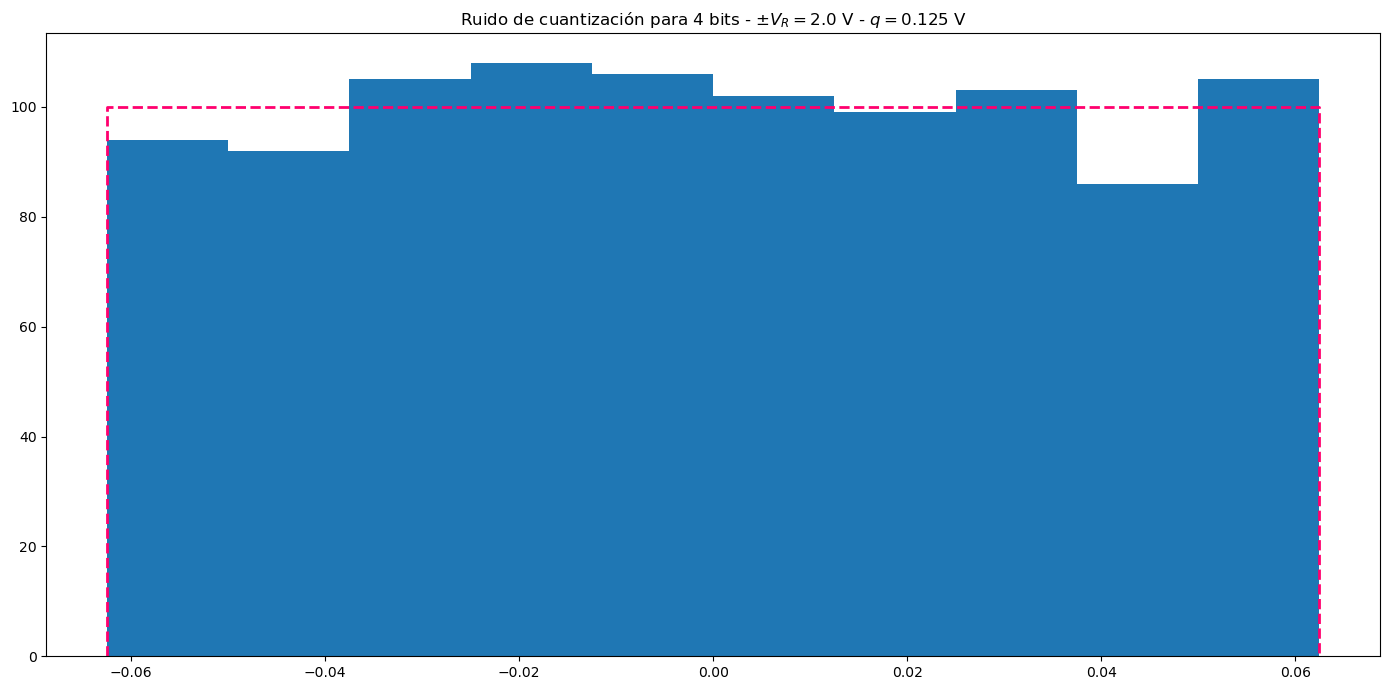

In [4]:
# Cálculo del error de cuantización
eq = sQ - sR

plt.figure(figsize=(14, 7))

counts, bins, patches = plt.hist(eq, bins=10, range=(-q/2, q/2), color='C0')

ideal_count = N / 10
plt.plot([-q/2, -q/2, q/2, q/2], [0, ideal_count, ideal_count, 0], '--', color='#FF006E', linewidth=2)

plt.title(f'Ruido de cuantización para {B} bits - $\pm V_R = {V_R}$ V - $q = {q}$ V')
plt.tight_layout()

plt.show()

Al analizar el histograma resultante, podemos confirmar empíricamente el comportamiento estadístico anticipado. 

Si bien la distribución real de los errores obtenida a partir de las muestras (barras azules) presenta fluctuaciones lógicas propias de una simulación finita, se ajusta de manera bastante fiel a la traza del modelo ideal (línea roja punteada), manteniendo un perfil predominantemente plano.

Además, queda en evidencia que la totalidad de las muestras del error de cuantización están estrictamente confinadas dentro del intervalo teórico esperado de $\pm \frac{q}{2}$. Dado que $q = 0.125$ V, los errores no superan los límites de -0.0625 V y 0.0625 V.

# Resolución del ejercicio 2

Para abordar esta segunda parte de la consigna, se introducen las variables de prueba $B_{\text{test}}$ y $k_{n\_\text{test}}$. 

El objetivo es flexibilizar la simulación para evaluar el impacto de distintas resoluciones y niveles de ruido, generando gráficos espectrales comparativos análogos a los del ejercicio anterior. Como se puede observar en el código, al modificar la resolución del ADC ($B$) o el factor de escala del ruido ($k_n$), resulta indispensable recalcular dinámicamente todas las métricas dependientes del sistema. Esto incluye: 
- El nuevo paso de cuantización ($q$).
- La potencia teórica del ruido de cuantización ($P_q$).
- La potencia del ruido gaussiano analógico ($P_n$).
- Y la consecuente regeneración de la secuencia de ruido y la señal digitalizada.

Vale la pena aclarar que, aunque la consigna solo pedía elegir un caso puntual ($B \in \{4, 8, 16\}$ bits y $k_n \in \{0.1, 1, 10\}$), podemos calcular y graficar todas las combinaciones posibles prácticamente sin esfuerzo extra.

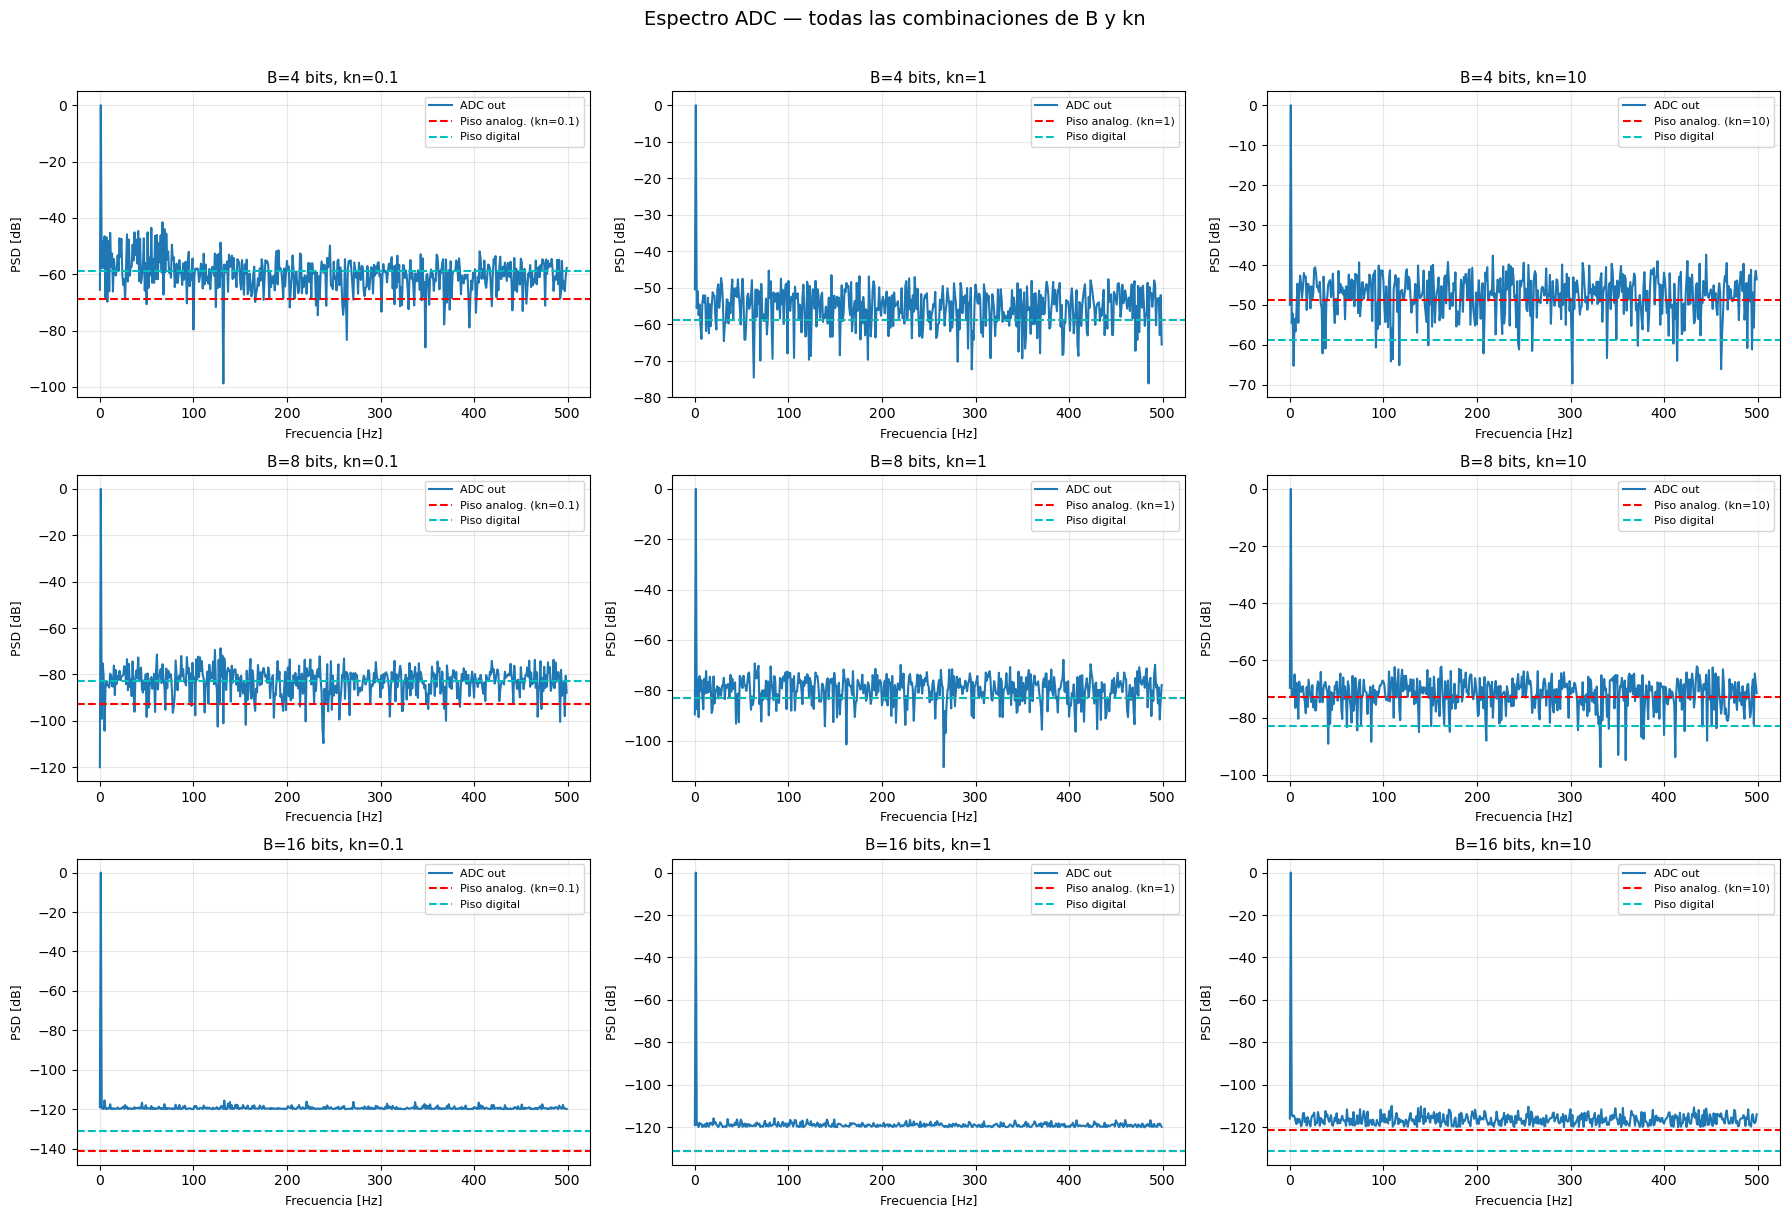

In [5]:
B_values = [4, 8, 16]
kn_values = [0.1, 1, 10]

eps = 1e-12

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, B in enumerate(B_values):
    for j, kn in enumerate(kn_values):
        q = (V_R) / (2**B)
        Pq = (q**2) / 12
        Pn = kn * Pq
        n = np.random.normal(0, np.sqrt(Pn), N)
        sR = s + n
        sQ = np.round(sR / q) * q
        SQ = np.fft.fft(sQ) / N
        psd_sQ = 10 * np.log10(2 * np.abs(SQ[:N//2])**2 + eps)
        floor_digital = 10 * np.log10(Pq / N)
        floor_analog = 10 * np.log10(Pn / N)

        ax = axes[i][j]
        ax.plot(pos_freqs, psd_sQ, label=f'ADC out', color='C0')
        ax.axhline(floor_analog, color='r', linestyle='--', label=f'Piso analog. (kn={kn})')
        ax.axhline(floor_digital, color='c', linestyle='--', label='Piso digital')
        ax.set_title(f'B={B} bits, kn={kn}', fontsize=11)
        ax.set_xlabel('Frecuencia [Hz]', fontsize=9)
        ax.set_ylabel('PSD [dB]', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Espectro ADC — todas las combinaciones de B y kn', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Además de los gráficos, se confeccionó una tabla con los valores de interés para una mejor comparación.

In [6]:
# Tabla con datos relevantes
headers = ['B [bits]', 'kn', 'q (paso)', 'Pq [W]', 'Pn [W]', 'Piso digital [dB]', 'Piso analógico [dB]', 'SQNR [dB]']
print(f"{'B':>6} {'kn':>6} {'q':>10} {'Pq':>12} {'Pn':>12} {'Piso digital':>14} {'Piso analógico':>14} {'SQNR':>6}")
print("-" * 100)

for B in B_values:
    for kn in kn_values:
        q = (V_R) / (2**B)
        Pq = (q**2) / 12
        Pn = kn * Pq
        floor_digital = 10 * np.log10(Pq / N)
        floor_analog  = 10 * np.log10(Pn / N)
        SQNR = 10 * np.log10(Pq / Pn)
        print(f"{B:>6} {kn:>6} {q:>10.6f} {Pq:>12.2e} {Pn:>12.2e} {floor_digital:>12.2f} {floor_analog:>12.2f} {SQNR:>10.2f}")

     B     kn          q           Pq           Pn   Piso digital Piso analógico   SQNR
----------------------------------------------------------------------------------------------------
     4    0.1   0.125000     1.30e-03     1.30e-04       -58.85       -68.85      10.00
     4      1   0.125000     1.30e-03     1.30e-03       -58.85       -58.85       0.00
     4     10   0.125000     1.30e-03     1.30e-02       -58.85       -48.85     -10.00
     8    0.1   0.007812     5.09e-06     5.09e-07       -82.94       -92.94      10.00
     8      1   0.007812     5.09e-06     5.09e-06       -82.94       -82.94       0.00
     8     10   0.007812     5.09e-06     5.09e-05       -82.94       -72.94     -10.00
    16    0.1   0.000031     7.76e-11     7.76e-12      -131.10      -141.10      10.00
    16      1   0.000031     7.76e-11     7.76e-11      -131.10      -131.10       0.00
    16     10   0.000031     7.76e-11     7.76e-10      -131.10      -121.10     -10.00




A partir del análisis de los espectros resultantes y la tabla de parámetros calculados, se pueden extraer varias conclusiones sobre el comportamiento del sistema.

En todos los escenarios simulados, queda en evidencia que el piso de ruido efectivo a la salida del ADC (traza azul) está dictaminado por la fuente de ruido de mayor potencia.
- Cuando $k_n = 0.1$, la potencia del ruido de cuantización es un orden de magnitud mayor que la del ruido analógico ($P_q > P_n$). En los gráficos correspondientes, se observa claramente cómo el espectro se recuesta sobre el Piso digital (línea cian), enmascarando por completo al ruido analógico.
- Por el contrario, cuando $k_n = 10$, el ruido analógico de entrada es el dominante ($P_n > P_q$), y el espectro de la señal digitalizada pasa a estar limitado por el Piso analógico (línea roja).

En la columna central de gráficos, se puede notar visualmente que la traza del ADC no se apoya sobre las líneas punteadas teóricas, sino que se ubica levemente por encima de ellas. Al ser el ruido analógico y el ruido de cuantización variables aleatorias independientes e incorreladas, sus potencias se suman linealmente ($P_{total} = P_q + P_n = 2P_q$). En escala logarítmica, esto se traduce en un incremento teórico del piso de ruido de 3 dB por encima de los pisos individuales calculados.

Al aumentar la resolución de 4 a 8, y luego a 16 bits, el paso de cuantización $q$ se achica de manera exponencial. Esto provoca un "hundimiento" del piso de ruido digital, mejorando la relación señal a ruido en aproximadamente 24 dB por cada salto de 4 bits que damos en la arquitectura del ADC (pasando de $\approx -58$ dB en 4 bits a $\approx -131$ dB en 16 bits).

Finalmente, cabe notar que la diferencia en decibeles entre el piso analógico y el piso digital se mantiene constante a lo ancho de las filas de la tabla (10 dB, 0 dB y -10 dB respectivamente). Esto es una consecuencia directa de la consigna de prueba, donde el ruido analógico se definió artificialmente atado a la resolución del convertidor mediante la expresión $P_n = k_n \cdot P_q$.

## Bonus
Para encontrar la relación teórica entre la Relación Señal a Ruido (SNR) y la cantidad de bits $B$ de un ADC, partimos de la definición de SNR en decibeles asumiendo una señal senoidal a plena escala (full-scale).La amplitud máxima de la senoidal para aprovechar todo el rango es $A = V_R$. Por lo tanto, la potencia de la señal senoidal es:
$$P_{signal} = \frac{A^2}{2} = \frac{V_R^2}{2}$$
La potencia del ruido de cuantización (asumiendo que es uniforme e incorrelado) es:
$$P_{noise} = \frac{q^2}{12}$$
Sabiendo que el paso de cuantización es $q = \frac{2 V_R}{2^B}$, reemplazamos en la potencia del ruido:
$$P_{noise} = \frac{\left(\frac{2 V_R}{2^B}\right)^2}{12} = \frac{4 V_R^2}{12 \cdot 2^{2B}} = \frac{V_R^2}{3 \cdot 2^{2B}}$$
Ahora, calculamos el SNR como el cociente de potencias:
$$SNR = \frac{P_{signal}}{P_{noise}} = \frac{V_R^2 / 2}{V_R^2 / (3 \cdot 2^{2B})} = \frac{3}{2} \cdot 2^{2B}$$
Pasando esto a decibeles ($10 \log_{10}$):$$SNR_{dB} = 10 \log_{10}(1.5) + 10 \log_{10}(2^{2B})$$
$$SNR_{dB} = 1.76 + 20 \cdot B \cdot \log_{10}(2)$$
Como $\log_{10}(2) \approx 0.301$, llegamos a:
$$SNR_{dB} \approx 6.02 \cdot B + 1.76$$

Conclusión: Cada bit adicional en el ADC mejora la relación señal-ruido en aproximadamente 6 dB.